# Programmatic regulatory-region discovery + AlphaGenome mutation scan

This notebook turns the FOXP3 exploration into a reportable workflow:

1. Retrieve gene coordinates from Ensembl.
2. Search nearby cis-regulatory annotations from Ensembl and UCSC/ENCODE cCREs.
3. Convert candidate regulatory annotations into 100-300 bp scan windows.
4. Run an AlphaGenome substitution scan across selected windows.
5. Rank variants, tracks, and regions by numeric sensitivity.
6. Save CSV summaries and heatmaps.

Default gene: **FOXP3**. You can rerun the same workflow for **BACH2** and **SATB1** by changing `gene_symbol`.

Practical recommendation: use `100KB` sequence length for discovery scans. After you identify top variants, rerun the original single-variant visualization notebook with `1MB` if you want publication-style REF vs ALT plots.

## 0. Install packages

Run this cell in Colab. If you are running locally and already have the packages installed, you can skip it.

In [14]:
# @title Install dependencies { display-mode: "form" }
install_packages = True  # @param {type:"boolean"}

if install_packages:
    from IPython.display import clear_output
    !pip -q install alphagenome pandas numpy matplotlib requests
    clear_output()
    print('Installed dependencies.')

Installed dependencies.


## 1. Imports and utility functions

This cell contains the helper functions used for gene lookup, regulatory annotation retrieval, candidate-window generation, sequence retrieval, and score summarization.

In [15]:
"""
Utilities for programmatic regulatory-region discovery and AlphaGenome mutation scanning.

Designed for the CS823 project workflow:
1. Retrieve gene coordinates from Ensembl.
2. Discover nearby regulatory annotations from Ensembl/UCSC ENCODE cCREs.
3. Convert annotations into small scan windows.
4. Build substitution variants and summarize AlphaGenome scores.

This module is optional: the accompanying notebook is self-contained, but these
functions are separated here for reuse in future notebooks/scripts.
"""

from __future__ import annotations

import os
import time
import json
import math
from dataclasses import dataclass
from typing import Iterable, Optional, Sequence

import numpy as np
import pandas as pd
import requests

ENSEMBL_REST = "https://rest.ensembl.org"
UCSC_API = "https://api.genome.ucsc.edu"
BASES = ["A", "C", "G", "T"]


def get_json(url: str, params: Optional[dict] = None, headers: Optional[dict] = None, retries: int = 3, sleep: float = 1.0) -> dict:
    """Small GET helper with retries."""
    headers = headers or {"Content-Type": "application/json"}
    last_exc = None
    for attempt in range(1, retries + 1):
        try:
            r = requests.get(url, params=params, headers=headers, timeout=60)
            r.raise_for_status()
            return r.json()
        except Exception as exc:  # noqa: BLE001
            last_exc = exc
            if attempt < retries:
                time.sleep(sleep * attempt)
    raise last_exc


def ensembl_get_json(endpoint: str, params: Optional[dict] = None, species_server: str = ENSEMBL_REST) -> dict:
    """Call Ensembl REST and return JSON."""
    return get_json(f"{species_server}{endpoint}", params=params, headers={"Content-Type": "application/json"})


def normalize_chrom(chrom: str, add_chr: bool = True) -> str:
    chrom = str(chrom)
    if add_chr and not chrom.startswith("chr"):
        return "chr" + chrom
    if not add_chr and chrom.startswith("chr"):
        return chrom.replace("chr", "", 1)
    return chrom


def get_gene_coordinates(symbol: str, species: str = "homo_sapiens") -> dict:
    """Retrieve gene coordinates from Ensembl by gene symbol.

    Ensembl returns 1-based inclusive coordinates. Chromosome is returned with
    a UCSC-style chr prefix for compatibility with AlphaGenome/UCSC.
    """
    data = ensembl_get_json(f"/lookup/symbol/{species}/{symbol}", params={"expand": 1})
    chrom = normalize_chrom(data["seq_region_name"], add_chr=True)
    strand = int(data["strand"])
    start = int(data["start"])
    end = int(data["end"])
    return {
        "symbol": symbol,
        "ensembl_id": data["id"],
        "chrom": chrom,
        "start": start,
        "end": end,
        "strand": strand,
        "tss": start if strand == 1 else end,
        "source": "Ensembl lookup/symbol",
    }


def expand_gene_region(gene: dict, flank: int = 100_000) -> dict:
    """Create a local cis-regulatory search interval around a gene."""
    return {
        "gene_symbol": gene["symbol"],
        "gene_start": int(gene["start"]),
        "gene_end": int(gene["end"]),
        "tss": int(gene["tss"]),
        "strand": int(gene["strand"]),
        "chrom": gene["chrom"],
        "start": max(1, int(gene["start"]) - flank),
        "end": int(gene["end"]) + flank,
        "flank": flank,
    }


def get_ensembl_regulatory_features(chrom: str, start: int, end: int, species: str = "human") -> pd.DataFrame:
    """Retrieve Ensembl regulatory features overlapping a region."""
    chrom_no_chr = normalize_chrom(chrom, add_chr=False)
    region = f"{chrom_no_chr}:{int(start)}..{int(end)}"
    data = ensembl_get_json(f"/overlap/region/{species}/{region}", params={"feature": "regulatory"})
    rows = []
    for x in data:
        rows.append({
            "source": "Ensembl regulatory",
            "id": x.get("id"),
            "chrom": normalize_chrom(x.get("seq_region_name", chrom), add_chr=True),
            "start": int(x.get("start")),
            "end": int(x.get("end")),
            "feature_type": x.get("feature_type"),
            "description": x.get("description"),
            "bound_start": int(x.get("bound_start", x.get("start"))),
            "bound_end": int(x.get("bound_end", x.get("end"))),
        })
    return pd.DataFrame(rows)


def ucsc_get_track(chrom: str, start: int, end: int, track: str = "encodeCcreCombined", genome: str = "hg38") -> pd.DataFrame:
    """Retrieve a UCSC track interval as a DataFrame."""
    params = {
        "genome": genome,
        "track": track,
        "chrom": chrom,
        # UCSC API uses 0-based start and half-open end for interval queries.
        "start": max(0, int(start) - 1),
        "end": int(end),
        "maxItemsOutput": 100000,
    }
    data = get_json(f"{UCSC_API}/getData/track", params=params)
    records = data.get(track, [])
    return pd.DataFrame(records)


def ucsc_get_sequence(chrom: str, start: int, end: int, genome: str = "hg38") -> str:
    """Fetch reference DNA for a 1-based inclusive interval from UCSC."""
    params = {
        "genome": genome,
        "chrom": chrom,
        "start": max(0, int(start) - 1),
        "end": int(end),
    }
    data = get_json(f"{UCSC_API}/getData/sequence", params=params)
    dna = data.get("dna", "")
    if not dna:
        raise ValueError(f"No sequence returned for {chrom}:{start}-{end}")
    return dna.upper()


def normalize_ucsc_ccres(df: pd.DataFrame, fallback_chrom: Optional[str] = None) -> pd.DataFrame:
    """Normalize UCSC cCRE columns to chrom/start/end/source/center."""
    if df is None or df.empty:
        return pd.DataFrame()
    out = df.copy()
    if "chromStart" in out.columns:
        out["start"] = out["chromStart"].astype(int) + 1  # convert 0-based start to 1-based for consistency
    elif "start" in out.columns:
        out["start"] = out["start"].astype(int)
    else:
        raise ValueError("Could not find UCSC start column")

    if "chromEnd" in out.columns:
        out["end"] = out["chromEnd"].astype(int)
    elif "end" in out.columns:
        out["end"] = out["end"].astype(int)
    else:
        raise ValueError("Could not find UCSC end column")

    if "chrom" not in out.columns:
        out["chrom"] = fallback_chrom
    out["chrom"] = out["chrom"].apply(lambda x: normalize_chrom(x, add_chr=True))
    out["source"] = "UCSC ENCODE cCRE"
    out["center"] = ((out["start"] + out["end"]) // 2).astype(int)
    return out


def combined_text(df: pd.DataFrame) -> pd.Series:
    """Combine text columns into one lowercase searchable string per row."""
    if df is None or df.empty:
        return pd.Series(dtype=str)
    text_cols = [c for c in df.columns if df[c].dtype == object]
    text = pd.Series("", index=df.index, dtype=str)
    for c in text_cols:
        text = text + " " + df[c].fillna("").astype(str).str.lower()
    return text


def filter_regulatory_candidates(df: pd.DataFrame) -> pd.DataFrame:
    """Keep promoter/enhancer/open-chromatin/cCRE-like annotations."""
    if df is None or df.empty:
        return pd.DataFrame()
    text = combined_text(df)
    keep = (
        text.str.contains("promoter")
        | text.str.contains("enhancer")
        | text.str.contains("open chromatin")
        | text.str.contains("pls")
        | text.str.contains("pels")
        | text.str.contains("dels")
        | text.str.contains("dnase")
        | text.str.contains("h3k4me3")
        | text.str.contains("h3k27ac")
        | text.str.contains("ctcf")
    )
    return df.loc[keep].copy()


def add_candidate_priority(df: pd.DataFrame, tss: Optional[int] = None) -> pd.DataFrame:
    """Add ranking columns for regulatory candidates."""
    if df is None or df.empty:
        return pd.DataFrame()
    out = df.copy()
    text = combined_text(out)
    out["candidate_class"] = np.select(
        [
            text.str.contains("pls") | text.str.contains("promoter"),
            text.str.contains("pels") | text.str.contains("proximal"),
            text.str.contains("dels") | text.str.contains("enhancer"),
            text.str.contains("dnase") | text.str.contains("open chromatin"),
            text.str.contains("ctcf"),
        ],
        ["promoter_like", "proximal_enhancer_like", "distal_enhancer_like", "open_chromatin", "ctcf_like"],
        default="other_regulatory",
    )
    class_priority = {
        "promoter_like": 5,
        "proximal_enhancer_like": 4,
        "distal_enhancer_like": 3,
        "open_chromatin": 2,
        "ctcf_like": 1,
        "other_regulatory": 0,
    }
    out["class_priority"] = out["candidate_class"].map(class_priority).fillna(0).astype(int)
    if "center" not in out.columns:
        out["center"] = ((out["start"].astype(int) + out["end"].astype(int)) // 2).astype(int)
    if tss is not None:
        out["distance_to_tss"] = (out["center"].astype(int) - int(tss)).abs()
    else:
        out["distance_to_tss"] = np.nan
    return out


def make_scan_windows_from_candidates(
    df: pd.DataFrame,
    gene_symbol: str,
    window_size: int = 300,
    max_regions: int = 20,
    min_gap: int = 100,
) -> pd.DataFrame:
    """Convert regulatory annotations into centered scan windows.

    min_gap merges/de-duplicates near-identical windows by keeping the first
    high-priority candidate when centers are very close.
    """
    if df is None or df.empty:
        return pd.DataFrame()
    rows = []
    half = window_size // 2
    for i, row in df.iterrows():
        center = int(row.get("center", (int(row["start"]) + int(row["end"])) // 2))
        region_id = row.get("name") or row.get("id") or row.get("accessionLabel") or f"{gene_symbol}_candidate_{i}"
        rows.append({
            "gene_symbol": gene_symbol,
            "region_id": str(region_id),
            "source": row.get("source", "unknown"),
            "candidate_class": row.get("candidate_class", "unknown"),
            "class_priority": int(row.get("class_priority", 0)),
            "chrom": row["chrom"],
            "start": max(1, center - half),
            "end": center + half,
            "center": center,
            "annotation_start": int(row["start"]),
            "annotation_end": int(row["end"]),
            "distance_to_tss": row.get("distance_to_tss", np.nan),
        })
    out = pd.DataFrame(rows)
    out = out.sort_values(["class_priority", "distance_to_tss"], ascending=[False, True])

    # De-duplicate very close windows after sorting.
    kept = []
    for _, row in out.iterrows():
        if all(abs(int(row["center"]) - int(k["center"])) >= min_gap for k in kept):
            kept.append(row.to_dict())
        if len(kept) >= max_regions:
            break
    return pd.DataFrame(kept)


def discover_candidate_regions_for_gene(
    gene_symbol: str,
    flank: int = 100_000,
    window_size: int = 300,
    max_regions: int = 20,
    genome: str = "hg38",
) -> tuple[dict, dict, pd.DataFrame, pd.DataFrame]:
    """High-level helper to discover candidate regulatory scan windows."""
    gene = get_gene_coordinates(gene_symbol)
    locus = expand_gene_region(gene, flank=flank)

    tables = []
    try:
        ens = get_ensembl_regulatory_features(locus["chrom"], locus["start"], locus["end"])
        ens = filter_regulatory_candidates(ens)
        if not ens.empty:
            ens["center"] = ((ens["start"].astype(int) + ens["end"].astype(int)) // 2).astype(int)
            tables.append(ens)
    except Exception as exc:  # noqa: BLE001
        print(f"Warning: Ensembl regulatory feature retrieval failed: {exc}")

    try:
        ccres = ucsc_get_track(locus["chrom"], locus["start"], locus["end"], track="encodeCcreCombined", genome=genome)
        ccres = normalize_ucsc_ccres(ccres, fallback_chrom=locus["chrom"])
        ccres = filter_regulatory_candidates(ccres)
        if not ccres.empty:
            tables.append(ccres)
    except Exception as exc:  # noqa: BLE001
        print(f"Warning: UCSC cCRE retrieval failed: {exc}")

    if tables:
        candidates = pd.concat(tables, ignore_index=True, sort=False)
        candidates = add_candidate_priority(candidates, tss=locus["tss"])
        candidates = candidates.sort_values(["class_priority", "distance_to_tss"], ascending=[False, True])
        windows = make_scan_windows_from_candidates(candidates, gene_symbol, window_size=window_size, max_regions=max_regions)
    else:
        candidates = pd.DataFrame()
        windows = pd.DataFrame()
    return gene, locus, candidates, windows


def build_substitution_variants(chrom: str, start: int, end: int, reference_sequence: str, step: int = 10, bases: Sequence[str] = BASES) -> pd.DataFrame:
    """Build all SNV substitutions across a 1-based inclusive region."""
    rows = []
    start = int(start)
    end = int(end)
    seq = reference_sequence.upper()
    for pos in range(start, end + 1, int(step)):
        idx = pos - start
        if idx < 0 or idx >= len(seq):
            continue
        ref = seq[idx]
        if ref not in bases:
            continue
        for alt in bases:
            if alt != ref:
                rows.append({
                    "chromosome": chrom,
                    "position": int(pos),
                    "reference_base": ref,
                    "alternate_base": alt,
                    "variant_id_custom": f"{chrom}:{pos}:{ref}>{alt}",
                })
    return pd.DataFrame(rows)


def detect_numeric_score_column(df: pd.DataFrame) -> str:
    """Detect a numeric AlphaGenome score column from tidy_scores output."""
    preferred = ["score", "variant_score", "raw_score", "value", "prediction", "delta"]
    for col in preferred:
        if col in df.columns and pd.api.types.is_numeric_dtype(df[col]):
            return col
    numeric_cols = [
        c for c in df.select_dtypes(include="number").columns
        if c not in {"position", "junction_Start", "junction_End", "annotation_start", "annotation_end"}
    ]
    if not numeric_cols:
        raise ValueError("Could not identify a numeric score column.")
    return numeric_cols[0]


def filter_score_rows(
    df_scores: pd.DataFrame,
    outputs_to_keep: Optional[Sequence[str]] = None,
    biosample_text_filters: Optional[Sequence[str]] = None,
) -> pd.DataFrame:
    """Filter AlphaGenome tidy score rows by output type and biosample text."""
    out = df_scores.copy()
    if outputs_to_keep:
        out = out[out["output_type"].isin(outputs_to_keep)].copy()
    if biosample_text_filters:
        searchable_cols = [
            c for c in out.columns
            if any(term in c.lower() for term in ["biosample", "ontology", "cell", "tissue", "name"])
        ]
        if searchable_cols:
            mask = pd.Series(False, index=out.index)
            for col in searchable_cols:
                text = out[col].astype(str)
                for token in biosample_text_filters:
                    mask = mask | text.str.contains(token, case=False, na=False)
            filtered = out[mask].copy()
            if len(filtered) > 0:
                out = filtered
    return out


def summarize_variant_scores(df_scores: pd.DataFrame, score_column: Optional[str] = None) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Create variant-level summary and track-level variance tables."""
    df = df_scores.copy()
    score_column = score_column or detect_numeric_score_column(df)
    df["score_numeric"] = pd.to_numeric(df[score_column], errors="coerce")
    df = df.dropna(subset=["score_numeric"]).copy()
    df["abs_score"] = df["score_numeric"].abs()

    group_cols = [
        "gene_symbol", "region_id", "chromosome", "position",
        "reference_base", "alternate_base", "variant_id_custom",
    ]
    group_cols = [c for c in group_cols if c in df.columns]
    idx = df.groupby(group_cols, dropna=False)["abs_score"].idxmax()
    keep_cols = group_cols + [
        c for c in ["output_type", "track_name", "biosample_name", "biosample_type", score_column, "score_numeric", "abs_score"]
        if c in df.columns
    ]
    variant_summary = df.loc[idx, keep_cols].sort_values("abs_score", ascending=False).reset_index(drop=True)
    variant_summary = variant_summary.rename(columns={score_column: "selected_track_score"})

    track_cols = [
        "gene_symbol", "region_id", "output_type", "track_name", "biosample_name", "biosample_type"
    ]
    track_cols = [c for c in track_cols if c in df.columns]
    track_variance = (
        df.groupby(track_cols, dropna=False)
        .agg(
            n_scores=("abs_score", "count"),
            n_variants=("variant_id_custom", "nunique"),
            max_abs_score=("abs_score", "max"),
            mean_abs_score=("abs_score", "mean"),
            score_variance=("abs_score", "var"),
        )
        .reset_index()
    )
    track_variance["score_variance"] = track_variance["score_variance"].fillna(0)
    track_variance = track_variance.sort_values(["score_variance", "max_abs_score"], ascending=False).reset_index(drop=True)
    return variant_summary, track_variance


def add_biological_relevance_score(df: pd.DataFrame, keywords: Optional[Sequence[str]] = None) -> pd.DataFrame:
    """Add a simple keyword-based relevance score for immune/Treg tracks."""
    keywords = keywords or ["regulatory t", "treg", "cd4", "cd25", "t cell", "lymphocyte", "immune"]
    out = df.copy()
    text_cols = [c for c in out.columns if out[c].dtype == object]
    text = pd.Series("", index=out.index, dtype=str)
    for c in text_cols:
        text = text + " " + out[c].fillna("").astype(str).str.lower()
    score = pd.Series(0, index=out.index, dtype=int)
    for kw in keywords:
        score = score + text.str.contains(kw.lower(), na=False).astype(int)
    out["bio_relevance_score"] = score
    return out

## 2. Project parameters

Start with FOXP3. Later, rerun the notebook with `BACH2` and `SATB1`.

The search process is intentionally separated from AlphaGenome scoring. This makes the region selection defensible in your report, because the candidate regions come from Ensembl/UCSC/ENCODE annotations rather than from manually eyeballing AlphaGenome plots.

In [16]:
# @title Set gene and region-discovery parameters { run: "auto" }
gene_symbol = 'SATB1'  # @param {type:"string"}

# Search local cis-regulatory neighborhood around the gene.
search_flank_bp = 100000  # @param {type:"integer"}

# Project proposal mentions 100-300 bp regions. 300 bp is a good starting size.
candidate_window_size_bp = 300  # @param {type:"integer"}

# Number of candidate regulatory windows to keep after annotation-based ranking.
max_candidate_regions = 20  # @param {type:"integer"}

# Genome assembly used by AlphaGenome tutorial for human.
ucsc_genome = 'hg38'  # @param ["hg38"] {type:"string"}

output_root = 'alphagenome_project_outputs'
os.makedirs(output_root, exist_ok=True)

gene_output_dir = os.path.join(output_root, gene_symbol.upper())
os.makedirs(gene_output_dir, exist_ok=True)

print('Output directory:', gene_output_dir)

Output directory: alphagenome_project_outputs/SATB1


## 3. Discover candidate regulatory regions programmatically

This cell uses:

- Ensembl lookup to get the gene coordinates.
- Ensembl overlap/regulatory features where available.
- UCSC ENCODE cCREs (`encodeCcreCombined`) as candidate regulatory annotations.

The resulting windows are ranked by annotation class and distance to the gene TSS.

In [17]:
# @title Discover regulatory annotations and scan windows
import json
from IPython.display import display

print(f'Discovering candidate regulatory regions for {gene_symbol}...')

gene_info, locus_info, candidate_annotations, candidate_scan_windows = discover_candidate_regions_for_gene(
    gene_symbol=gene_symbol,
    flank=search_flank_bp,
    window_size=candidate_window_size_bp,
    max_regions=max_candidate_regions,
    genome=ucsc_genome,
)

print('Gene coordinates:')
print(json.dumps(gene_info, indent=2))
print('\nSearch locus:')
print(json.dumps(locus_info, indent=2))

# Save outputs.
with open(os.path.join(gene_output_dir, f'{gene_symbol}_gene_coordinates.json'), 'w') as f:
    json.dump(gene_info, f, indent=2)
with open(os.path.join(gene_output_dir, f'{gene_symbol}_search_locus.json'), 'w') as f:
    json.dump(locus_info, f, indent=2)

candidate_annotations.to_csv(os.path.join(gene_output_dir, f'{gene_symbol}_candidate_annotations.csv'), index=False)
candidate_scan_windows.to_csv(os.path.join(gene_output_dir, f'{gene_symbol}_candidate_scan_windows.csv'), index=False)

print(f'\nCandidate annotations: {len(candidate_annotations)}')
print(f'Candidate scan windows: {len(candidate_scan_windows)}')

print('\nTop candidate scan windows:')
display(candidate_scan_windows.head(20))


Discovering candidate regulatory regions for SATB1...
Gene coordinates:
{
  "symbol": "SATB1",
  "ensembl_id": "ENSG00000182568",
  "chrom": "chr3",
  "start": 18345377,
  "end": 18445621,
  "strand": -1,
  "tss": 18445621,
  "source": "Ensembl lookup/symbol"
}

Search locus:
{
  "gene_symbol": "SATB1",
  "gene_start": 18345377,
  "gene_end": 18445621,
  "tss": 18445621,
  "strand": -1,
  "chrom": "chr3",
  "start": 18245377,
  "end": 18545621,
  "flank": 100000
}

Candidate annotations: 120
Candidate scan windows: 20

Top candidate scan windows:


,gene_symbol,region_id,source,candidate_class,class_priority,chrom,start,end,center,annotation_start,annotation_end,distance_to_tss
0,SATB1,nan,Ensembl regulatory,promoter_like,5,chr3,18445699,18445999,18445849,18445588,18446111,228
1,SATB1,EH38E2183626,UCSC ENCODE cCRE,promoter_like,5,chr3,18445079,18445379,18445229,18445092,18445366,392
2,SATB1,EH38E2183625,UCSC ENCODE cCRE,promoter_like,5,chr3,18444701,18445001,18444851,18444678,18445025,770
3,SATB1,nan,Ensembl regulatory,promoter_like,5,chr3,18438708,18439008,18438858,18438763,18438953,6763
4,SATB1,EH38E2183609,UCSC ENCODE cCRE,promoter_like,5,chr3,18438592,18438892,18438742,18438568,18438916,6879
5,SATB1,nan,Ensembl regulatory,promoter_like,5,chr3,18425414,18425714,18425564,18425300,18425829,20057
6,SATB1,EH38E2183584,UCSC ENCODE cCRE,promoter_like,5,chr3,18425306,18425606,18425456,18425351,18425562,20165
7,SATB1,nan,Ensembl regulatory,promoter_like,5,chr3,18424746,18425046,18424896,18424563,18425230,20725
8,SATB1,EH38E2183581,UCSC ENCODE cCRE,promoter_like,5,chr3,18424481,18424781,18424631,18424525,18424737,20990
9,SATB1,EH38E2183559,UCSC ENCODE cCRE,promoter_like,5,chr3,18409337,18409637,18409487,18409324,18409651,36134


## 4. Inspect candidate windows before scoring

Use this table to choose how many windows to scan. Start small. Scanning 3 windows at 300 bp with a 10 bp step is already about 90 variants.

A good first pass is:

- `max_windows_to_scan = 3`
- `scan_step_bp = 10`
- `scan_sequence_length_label = "100KB"`

Once the workflow is working, you can increase the number of windows or use a 5 bp step.

In [18]:
# @title Select windows for AlphaGenome scanning { run: "auto" }
# Leave selected_region_ids empty to scan the first N annotation-ranked windows.
selected_region_ids = []  # @param {type:"raw"}
max_windows_to_scan = 3  # @param {type:"integer"}

if selected_region_ids:
    windows_to_scan = candidate_scan_windows[candidate_scan_windows['region_id'].isin(selected_region_ids)].copy()
else:
    windows_to_scan = candidate_scan_windows.head(max_windows_to_scan).copy()

if windows_to_scan.empty:
    raise RuntimeError('No windows selected. Check candidate_scan_windows or selected_region_ids.')

print(f'Selected {len(windows_to_scan)} windows for scanning:')
display(windows_to_scan)

Selected 3 windows for scanning:


,gene_symbol,region_id,source,candidate_class,class_priority,chrom,start,end,center,annotation_start,annotation_end,distance_to_tss
0,SATB1,nan,Ensembl regulatory,promoter_like,5,chr3,18445699,18445999,18445849,18445588,18446111,228
1,SATB1,EH38E2183626,UCSC ENCODE cCRE,promoter_like,5,chr3,18445079,18445379,18445229,18445092,18445366,392
2,SATB1,EH38E2183625,UCSC ENCODE cCRE,promoter_like,5,chr3,18444701,18445001,18444851,18444678,18445025,770


## 5. Initialize AlphaGenome

This requires your AlphaGenome API key. The standard AlphaGenome Colab helper will prompt for it.

In [19]:
# @title Initialize AlphaGenome client
from alphagenome import colab_utils
from alphagenome.data import genome
from alphagenome.models import dna_client, variant_scorers
from google.colab import files

# Create model client. In Colab, this prompts for your AlphaGenome API key if needed.
dna_model = dna_client.create(colab_utils.get_api_key())
organism = dna_client.Organism.HOMO_SAPIENS
print('AlphaGenome client initialized.')

AlphaGenome client initialized.


## 6. AlphaGenome scan settings

The scan tests all possible single-nucleotide substitutions at sampled positions inside each selected candidate window.

No per-variant plots are generated here. The notebook saves numeric outputs and heatmaps, which are much easier to interpret.

In [20]:
# @title Configure mutation scan { run: "auto" }
scan_sequence_length_label = '100KB'  # @param ["2KB", "16KB", "100KB", "500KB", "1MB"] {type:"string"}
scan_step_bp = 10  # @param {type:"integer"}
max_variants_per_window = 90  # @param {type:"integer"}

# AlphaGenome output modalities most relevant to regulatory DNA.
outputs_to_keep = ['ATAC', 'DNASE', 'CHIP_HISTONE', 'CAGE']  # @param {type:"raw"}

# Prefer immune/T-cell/Treg-related tracks. If this filter would produce zero rows,
# the helper keeps the broader result instead of failing.
biosample_text_filters = ['regulatory T', 'T cell', 'CD4', 'CD25', 'lymphocyte', 'immune']  # @param {type:"raw"}

# Save all scan outputs.
download_scan_outputs = False  # @param {type:"boolean"}

scan_sequence_length = dna_client.SUPPORTED_SEQUENCE_LENGTHS[
    f'SEQUENCE_LENGTH_{scan_sequence_length_label}'
]

print('Sequence length:', scan_sequence_length_label)
print('Step:', scan_step_bp)
print('Outputs:', outputs_to_keep)
print('Biosample filters:', biosample_text_filters)

Sequence length: 100KB
Step: 10
Outputs: ['ATAC', 'DNASE', 'CHIP_HISTONE', 'CAGE']
Biosample filters: ['regulatory T', 'T cell', 'CD4', 'CD25', 'lymphocyte', 'immune']


## 7. Run AlphaGenome mutation scan

This can take time. Start with a few windows and a 10 bp step. Increase coverage only after this first run works.

In [21]:
# @title Run mutation scan
from IPython.display import display

all_score_tables = []
failed_variants = []
all_candidate_variants = []

for region_idx, region in windows_to_scan.reset_index(drop=True).iterrows():
    region_id = str(region['region_id'])
    chrom = str(region['chrom'])
    start = int(region['start'])
    end = int(region['end'])

    print(f'\n=== Region {region_idx + 1}/{len(windows_to_scan)}: {region_id} {chrom}:{start}-{end} ===')

    ref_seq = ucsc_get_sequence(chrom, start, end, genome=ucsc_genome)
    variants_df = build_substitution_variants(chrom, start, end, ref_seq, step=scan_step_bp)
    variants_df['gene_symbol'] = gene_symbol
    variants_df['region_id'] = region_id
    variants_df['region_start'] = start
    variants_df['region_end'] = end
    variants_df['candidate_class'] = region.get('candidate_class', 'unknown')
    all_candidate_variants.append(variants_df)

    if max_variants_per_window and len(variants_df) > max_variants_per_window:
        print(f'Capping region from {len(variants_df)} to {max_variants_per_window} variants.')
        variants_df = variants_df.head(max_variants_per_window).copy()

    print(f'Scoring {len(variants_df)} variants in this region...')

    for i, v in variants_df.reset_index(drop=True).iterrows():
        test_variant = genome.Variant(
            chromosome=v['chromosome'],
            position=int(v['position']),
            reference_bases=v['reference_base'],
            alternate_bases=v['alternate_base'],
        )
        test_interval = test_variant.reference_interval.resize(scan_sequence_length)

        try:
            scores = dna_model.score_variant(
                interval=test_interval,
                variant=test_variant,
                variant_scorers=list(variant_scorers.RECOMMENDED_VARIANT_SCORERS.values()),
            )
            tidy = variant_scorers.tidy_scores(scores)

            # Add metadata to every score row.
            tidy['gene_symbol'] = gene_symbol
            tidy['region_id'] = region_id
            tidy['region_start'] = start
            tidy['region_end'] = end
            tidy['candidate_class'] = region.get('candidate_class', 'unknown')
            tidy['chromosome'] = v['chromosome']
            tidy['position'] = int(v['position'])
            tidy['reference_base'] = v['reference_base']
            tidy['alternate_base'] = v['alternate_base']
            tidy['variant_id_custom'] = v['variant_id_custom']
            all_score_tables.append(tidy)

        except Exception as exc:
            failed_variants.append({
                'gene_symbol': gene_symbol,
                'region_id': region_id,
                'variant': str(test_variant),
                'error': repr(exc),
            })
            print(f'Failed {test_variant}: {exc}')

        if (i + 1) % 10 == 0 or (i + 1) == len(variants_df):
            print(f'  Completed {i + 1}/{len(variants_df)} variants')

if not all_score_tables:
    raise RuntimeError('No AlphaGenome scores were produced. Check failed_variants or API configuration.')

df_all_scores = pd.concat(all_score_tables, ignore_index=True)
df_candidate_variants = pd.concat(all_candidate_variants, ignore_index=True)

print('\nFinished scan.')
print('All scores:', df_all_scores.shape)
print('Candidate variants:', df_candidate_variants.shape)

if failed_variants:
    df_failed_variants = pd.DataFrame(failed_variants)
    print(f'Failed variants: {len(df_failed_variants)}')
    display(df_failed_variants.head(20))
else:
    df_failed_variants = pd.DataFrame()
    print('No failed variants.')

display(df_all_scores.head())



=== Region 1/3: nan chr3:18445699-18445999 ===
Capping region from 93 to 90 variants.
Scoring 90 variants in this region...
  Completed 10/90 variants
  Completed 20/90 variants
  Completed 30/90 variants
  Completed 40/90 variants
  Completed 50/90 variants
  Completed 60/90 variants
  Completed 70/90 variants
  Completed 80/90 variants
  Completed 90/90 variants

=== Region 2/3: EH38E2183626 chr3:18445079-18445379 ===
Capping region from 93 to 90 variants.
Scoring 90 variants in this region...
  Completed 10/90 variants
  Completed 20/90 variants
  Completed 30/90 variants
  Completed 40/90 variants
  Completed 50/90 variants
  Completed 60/90 variants
  Completed 70/90 variants
  Completed 80/90 variants
  Completed 90/90 variants

=== Region 3/3: EH38E2183625 chr3:18444701-18445001 ===
Capping region from 93 to 90 variants.
Scoring 90 variants in this region...
  Completed 10/90 variants
  Completed 20/90 variants
  Completed 30/90 variants
  Completed 40/90 variants
  Completed 5

,variant_id,scored_interval,gene_id,gene_name,gene_type,gene_strand,junction_Start,junction_End,output_type,variant_scorer,...,gene_symbol,region_id,region_start,region_end,candidate_class,chromosome,position,reference_base,alternate_base,variant_id_custom
0,chr3:18445699:G>A,chr3:18380163-18511235:.,None,None,None,None,None,None,ATAC,"CenterMaskScorer(requested_output=ATAC, width=...",...,SATB1,nan,18445699,18445999,promoter_like,chr3,18445699,G,A,chr3:18445699:G>A
1,chr3:18445699:G>A,chr3:18380163-18511235:.,None,None,None,None,None,None,ATAC,"CenterMaskScorer(requested_output=ATAC, width=...",...,SATB1,nan,18445699,18445999,promoter_like,chr3,18445699,G,A,chr3:18445699:G>A
2,chr3:18445699:G>A,chr3:18380163-18511235:.,None,None,None,None,None,None,ATAC,"CenterMaskScorer(requested_output=ATAC, width=...",...,SATB1,nan,18445699,18445999,promoter_like,chr3,18445699,G,A,chr3:18445699:G>A
3,chr3:18445699:G>A,chr3:18380163-18511235:.,None,None,None,None,None,None,ATAC,"CenterMaskScorer(requested_output=ATAC, width=...",...,SATB1,nan,18445699,18445999,promoter_like,chr3,18445699,G,A,chr3:18445699:G>A
4,chr3:18445699:G>A,chr3:18380163-18511235:.,None,None,None,None,None,None,ATAC,"CenterMaskScorer(requested_output=ATAC, width=...",...,SATB1,nan,18445699,18445999,promoter_like,chr3,18445699,G,A,chr3:18445699:G>A


## 8. Filter scores, rank variants, and rank tracks

This creates two key outputs:

1. **Variant summary:** one selected score per tested mutation.
2. **Track variance:** which tracks vary most across mutations.

For the report, use track variance plus biological relevance. A high-variance immune/Treg-relevant H3K27ac/ATAC/DNase/CAGE track is more useful than a high-variance unrelated cell line track.

In [22]:
# @title Summarize scan outputs
from IPython.display import display

# Filter rows to regulatory outputs and, when possible, immune/T-cell/Treg-related biosamples.
df_filtered_scores = filter_score_rows(
    df_all_scores,
    outputs_to_keep=outputs_to_keep,
    biosample_text_filters=biosample_text_filters,
)

score_column = detect_numeric_score_column(df_filtered_scores)
print('Using score column:', score_column)
print('Rows before filtering:', len(df_all_scores))
print('Rows after filtering:', len(df_filtered_scores))

variant_summary, track_variance = summarize_variant_scores(df_filtered_scores, score_column=score_column)
variant_summary = add_biological_relevance_score(variant_summary, keywords=biosample_text_filters)
track_variance = add_biological_relevance_score(track_variance, keywords=biosample_text_filters)

# Two useful rankings.
variant_summary_by_score = variant_summary.sort_values(['abs_score'], ascending=False).reset_index(drop=True)
variant_summary_bio_ranked = variant_summary.sort_values(
    ['bio_relevance_score', 'abs_score'], ascending=[False, False]
).reset_index(drop=True)

track_variance_by_variance = track_variance.sort_values(
    ['score_variance', 'max_abs_score'], ascending=[False, False]
).reset_index(drop=True)
track_variance_bio_ranked = track_variance.sort_values(
    ['bio_relevance_score', 'score_variance', 'max_abs_score'], ascending=[False, False, False]
).reset_index(drop=True)

print('\nTop variants by absolute AlphaGenome score:')
display(variant_summary_by_score.head(20))

print('\nTop biologically relevant variants, if matching biosample terms exist:')
display(variant_summary_bio_ranked.head(20))

print('\nTop tracks by score variance:')
display(track_variance_by_variance.head(20))

print('\nTop biologically relevant tracks by variance:')
display(track_variance_bio_ranked.head(20))


Using score column: raw_score
Rows before filtering: 3913430
Rows after filtering: 44820

Top variants by absolute AlphaGenome score:


,gene_symbol,region_id,chromosome,position,reference_base,alternate_base,variant_id_custom,output_type,track_name,biosample_name,biosample_type,selected_track_score,score_numeric,abs_score,bio_relevance_score
0,SATB1,EH38E2183625,chr3,18444811,G,C,chr3:18444811:G>C,CHIP_HISTONE,CL:0000624 Histone ChIP-seq H3K4me3,"CD4-positive, alpha-beta T cell",primary_cell,158780.0,158780.0,158780.0,2
1,SATB1,EH38E2183625,chr3,18444811,G,A,chr3:18444811:G>A,CHIP_HISTONE,CL:0000624 Histone ChIP-seq H3K4me3,"CD4-positive, alpha-beta T cell",primary_cell,156924.0,156924.0,156924.0,2
2,SATB1,EH38E2183625,chr3,18444811,G,T,chr3:18444811:G>T,CHIP_HISTONE,CL:0000624 Histone ChIP-seq H3K4me3,"CD4-positive, alpha-beta T cell",primary_cell,156924.0,156924.0,156924.0,2
3,SATB1,EH38E2183625,chr3,18444731,C,T,chr3:18444731:C>T,CHIP_HISTONE,CL:0000624 Histone ChIP-seq H3K4me3,"CD4-positive, alpha-beta T cell",primary_cell,156448.0,156448.0,156448.0,2
4,SATB1,EH38E2183625,chr3,18444731,C,A,chr3:18444731:C>A,CHIP_HISTONE,CL:0000624 Histone ChIP-seq H3K4me3,"CD4-positive, alpha-beta T cell",primary_cell,156320.0,156320.0,156320.0,2
5,SATB1,EH38E2183625,chr3,18444831,A,C,chr3:18444831:A>C,CHIP_HISTONE,CL:0000624 Histone ChIP-seq H3K4me3,"CD4-positive, alpha-beta T cell",primary_cell,155588.0,155588.0,155588.0,2
6,SATB1,EH38E2183625,chr3,18444831,A,T,chr3:18444831:A>T,CHIP_HISTONE,CL:0000624 Histone ChIP-seq H3K4me3,"CD4-positive, alpha-beta T cell",primary_cell,155152.0,155152.0,155152.0,2
7,SATB1,EH38E2183625,chr3,18444831,A,G,chr3:18444831:A>G,CHIP_HISTONE,CL:0000624 Histone ChIP-seq H3K4me3,"CD4-positive, alpha-beta T cell",primary_cell,155152.0,155152.0,155152.0,2
8,SATB1,EH38E2183625,chr3,18444791,C,T,chr3:18444791:C>T,CHIP_HISTONE,CL:0000624 Histone ChIP-seq H3K4me3,"CD4-positive, alpha-beta T cell",primary_cell,155072.0,155072.0,155072.0,2
9,SATB1,EH38E2183625,chr3,18444931,G,A,chr3:18444931:G>A,CHIP_HISTONE,CL:0000624 Histone ChIP-seq H3K4me3,"CD4-positive, alpha-beta T cell",primary_cell,154752.0,154752.0,154752.0,2



Top biologically relevant variants, if matching biosample terms exist:


,gene_symbol,region_id,chromosome,position,reference_base,alternate_base,variant_id_custom,output_type,track_name,biosample_name,biosample_type,selected_track_score,score_numeric,abs_score,bio_relevance_score
0,SATB1,EH38E2183625,chr3,18444811,G,C,chr3:18444811:G>C,CHIP_HISTONE,CL:0000624 Histone ChIP-seq H3K4me3,"CD4-positive, alpha-beta T cell",primary_cell,158780.0,158780.0,158780.0,2
1,SATB1,EH38E2183625,chr3,18444811,G,T,chr3:18444811:G>T,CHIP_HISTONE,CL:0000624 Histone ChIP-seq H3K4me3,"CD4-positive, alpha-beta T cell",primary_cell,156924.0,156924.0,156924.0,2
2,SATB1,EH38E2183625,chr3,18444811,G,A,chr3:18444811:G>A,CHIP_HISTONE,CL:0000624 Histone ChIP-seq H3K4me3,"CD4-positive, alpha-beta T cell",primary_cell,156924.0,156924.0,156924.0,2
3,SATB1,EH38E2183625,chr3,18444731,C,T,chr3:18444731:C>T,CHIP_HISTONE,CL:0000624 Histone ChIP-seq H3K4me3,"CD4-positive, alpha-beta T cell",primary_cell,156448.0,156448.0,156448.0,2
4,SATB1,EH38E2183625,chr3,18444731,C,A,chr3:18444731:C>A,CHIP_HISTONE,CL:0000624 Histone ChIP-seq H3K4me3,"CD4-positive, alpha-beta T cell",primary_cell,156320.0,156320.0,156320.0,2
5,SATB1,EH38E2183625,chr3,18444831,A,C,chr3:18444831:A>C,CHIP_HISTONE,CL:0000624 Histone ChIP-seq H3K4me3,"CD4-positive, alpha-beta T cell",primary_cell,155588.0,155588.0,155588.0,2
6,SATB1,EH38E2183625,chr3,18444831,A,T,chr3:18444831:A>T,CHIP_HISTONE,CL:0000624 Histone ChIP-seq H3K4me3,"CD4-positive, alpha-beta T cell",primary_cell,155152.0,155152.0,155152.0,2
7,SATB1,EH38E2183625,chr3,18444831,A,G,chr3:18444831:A>G,CHIP_HISTONE,CL:0000624 Histone ChIP-seq H3K4me3,"CD4-positive, alpha-beta T cell",primary_cell,155152.0,155152.0,155152.0,2
8,SATB1,EH38E2183625,chr3,18444791,C,T,chr3:18444791:C>T,CHIP_HISTONE,CL:0000624 Histone ChIP-seq H3K4me3,"CD4-positive, alpha-beta T cell",primary_cell,155072.0,155072.0,155072.0,2
9,SATB1,EH38E2183625,chr3,18444931,G,A,chr3:18444931:G>A,CHIP_HISTONE,CL:0000624 Histone ChIP-seq H3K4me3,"CD4-positive, alpha-beta T cell",primary_cell,154752.0,154752.0,154752.0,2



Top tracks by score variance:


,gene_symbol,region_id,output_type,track_name,biosample_name,biosample_type,n_scores,n_variants,max_abs_score,mean_abs_score,score_variance,bio_relevance_score
0,SATB1,EH38E2183625,CHIP_HISTONE,CL:0000624 Histone ChIP-seq H3K4me3,"CD4-positive, alpha-beta T cell",primary_cell,180,90,158780.00,75757.164062,5.774836e+09,2
1,SATB1,EH38E2183626,CHIP_HISTONE,CL:0000624 Histone ChIP-seq H3K4me3,"CD4-positive, alpha-beta T cell",primary_cell,180,90,150024.00,69782.265625,4.912424e+09,2
2,SATB1,EH38E2183625,CHIP_HISTONE,CL:0000625 Histone ChIP-seq H3K4me3,"CD8-positive, alpha-beta T cell",primary_cell,180,90,121774.00,58621.238281,3.457720e+09,1
3,SATB1,EH38E2183626,CHIP_HISTONE,CL:0000625 Histone ChIP-seq H3K4me3,"CD8-positive, alpha-beta T cell",primary_cell,180,90,116548.00,54166.171875,2.960317e+09,1
4,SATB1,nan,CHIP_HISTONE,CL:0000624 Histone ChIP-seq H3K4me3,"CD4-positive, alpha-beta T cell",primary_cell,180,90,93352.00,40384.273438,1.654865e+09,2
5,SATB1,nan,CHIP_HISTONE,CL:0000625 Histone ChIP-seq H3K4me3,"CD8-positive, alpha-beta T cell",primary_cell,180,90,71888.00,30514.572266,9.468364e+08,1
6,SATB1,EH38E2183626,CHIP_HISTONE,CL:0000895 Histone ChIP-seq H3K27ac,"naive thymus-derived CD4-positive, alpha-beta ...",primary_cell,180,90,50176.00,24109.652344,5.849723e+08,2
7,SATB1,EH38E2183625,CHIP_HISTONE,CL:0000895 Histone ChIP-seq H3K27ac,"naive thymus-derived CD4-positive, alpha-beta ...",primary_cell,180,90,49768.00,23984.675781,5.788915e+08,2
8,SATB1,EH38E2183626,CHIP_HISTONE,CL:0000792 Histone ChIP-seq H3K27ac,"CD4-positive, CD25-positive, alpha-beta regula...",primary_cell,180,90,48508.00,22964.521484,5.309651e+08,4
9,SATB1,EH38E2183625,CHIP_HISTONE,CL:0000792 Histone ChIP-seq H3K27ac,"CD4-positive, CD25-positive, alpha-beta regula...",primary_cell,180,90,58840.00,22127.820312,4.943345e+08,4



Top biologically relevant tracks by variance:


,gene_symbol,region_id,output_type,track_name,biosample_name,biosample_type,n_scores,n_variants,max_abs_score,mean_abs_score,score_variance,bio_relevance_score
0,SATB1,EH38E2183626,CHIP_HISTONE,CL:0000792 Histone ChIP-seq H3K27ac,"CD4-positive, CD25-positive, alpha-beta regula...",primary_cell,180,90,48508.000000,22964.521484,5.309651e+08,4
1,SATB1,EH38E2183625,CHIP_HISTONE,CL:0000792 Histone ChIP-seq H3K27ac,"CD4-positive, CD25-positive, alpha-beta regula...",primary_cell,180,90,58840.000000,22127.820312,4.943345e+08,4
2,SATB1,EH38E2183626,CHIP_HISTONE,CL:0000792 Histone ChIP-seq H3K4me3,"CD4-positive, CD25-positive, alpha-beta regula...",primary_cell,180,90,44055.500000,21122.248047,4.491893e+08,4
3,SATB1,EH38E2183625,CHIP_HISTONE,CL:0000792 Histone ChIP-seq H3K4me3,"CD4-positive, CD25-positive, alpha-beta regula...",primary_cell,180,90,44437.250000,20435.914062,4.208320e+08,4
4,SATB1,nan,CHIP_HISTONE,CL:0000792 Histone ChIP-seq H3K4me3,"CD4-positive, CD25-positive, alpha-beta regula...",primary_cell,180,90,38362.750000,17939.523438,3.243461e+08,4
5,SATB1,nan,CHIP_HISTONE,CL:0000792 Histone ChIP-seq H3K27ac,"CD4-positive, CD25-positive, alpha-beta regula...",primary_cell,180,90,43828.000000,16889.929688,2.908575e+08,4
6,SATB1,nan,CHIP_HISTONE,CL:0000792 Histone ChIP-seq H3K4me1,"CD4-positive, CD25-positive, alpha-beta regula...",primary_cell,180,90,7500.750000,3539.537842,1.262547e+07,4
7,SATB1,EH38E2183626,CHIP_HISTONE,CL:0000792 Histone ChIP-seq H3K4me1,"CD4-positive, CD25-positive, alpha-beta regula...",primary_cell,180,90,7278.500000,3500.594482,1.233112e+07,4
8,SATB1,EH38E2183625,CHIP_HISTONE,CL:0000792 Histone ChIP-seq H3K4me1,"CD4-positive, CD25-positive, alpha-beta regula...",primary_cell,180,90,6906.000000,3277.697998,1.080907e+07,4
9,SATB1,EH38E2183625,CHIP_HISTONE,CL:0000792 Histone ChIP-seq H3K36me3,"CD4-positive, CD25-positive, alpha-beta regula...",primary_cell,180,90,3304.250000,1479.654175,2.214091e+06,4


## 9. Save CSV outputs

These files are the main numerical results for your report.

In [23]:
# @title Save output tables
safe_gene = gene_symbol.upper().replace(' ', '_')

paths = {
    'candidate_variants': os.path.join(gene_output_dir, f'{safe_gene}_candidate_variants.csv'),
    'all_scores': os.path.join(gene_output_dir, f'{safe_gene}_alphagenome_all_scores.csv'),
    'filtered_scores': os.path.join(gene_output_dir, f'{safe_gene}_alphagenome_filtered_scores.csv'),
    'variant_summary': os.path.join(gene_output_dir, f'{safe_gene}_alphagenome_variant_summary.csv'),
    'variant_summary_bio_ranked': os.path.join(gene_output_dir, f'{safe_gene}_alphagenome_variant_summary_bio_ranked.csv'),
    'track_variance': os.path.join(gene_output_dir, f'{safe_gene}_alphagenome_track_variance.csv'),
    'track_variance_bio_ranked': os.path.join(gene_output_dir, f'{safe_gene}_alphagenome_track_variance_bio_ranked.csv'),
}

df_candidate_variants.to_csv(paths['candidate_variants'], index=False)
df_all_scores.to_csv(paths['all_scores'], index=False)
df_filtered_scores.to_csv(paths['filtered_scores'], index=False)
variant_summary_by_score.to_csv(paths['variant_summary'], index=False)
variant_summary_bio_ranked.to_csv(paths['variant_summary_bio_ranked'], index=False)
track_variance_by_variance.to_csv(paths['track_variance'], index=False)
track_variance_bio_ranked.to_csv(paths['track_variance_bio_ranked'], index=False)

for label, path in paths.items():
    print(f'{label}: {path}')

candidate_variants: alphagenome_project_outputs/SATB1/SATB1_candidate_variants.csv
all_scores: alphagenome_project_outputs/SATB1/SATB1_alphagenome_all_scores.csv
filtered_scores: alphagenome_project_outputs/SATB1/SATB1_alphagenome_filtered_scores.csv
variant_summary: alphagenome_project_outputs/SATB1/SATB1_alphagenome_variant_summary.csv
variant_summary_bio_ranked: alphagenome_project_outputs/SATB1/SATB1_alphagenome_variant_summary_bio_ranked.csv
track_variance: alphagenome_project_outputs/SATB1/SATB1_alphagenome_track_variance.csv
track_variance_bio_ranked: alphagenome_project_outputs/SATB1/SATB1_alphagenome_track_variance_bio_ranked.csv


## 10. Generate heatmaps

This creates one heatmap per scanned region. The rows are alternate bases and columns are genomic positions. Larger values indicate stronger predicted AlphaGenome variant effect under the selected scoring/filtering method.

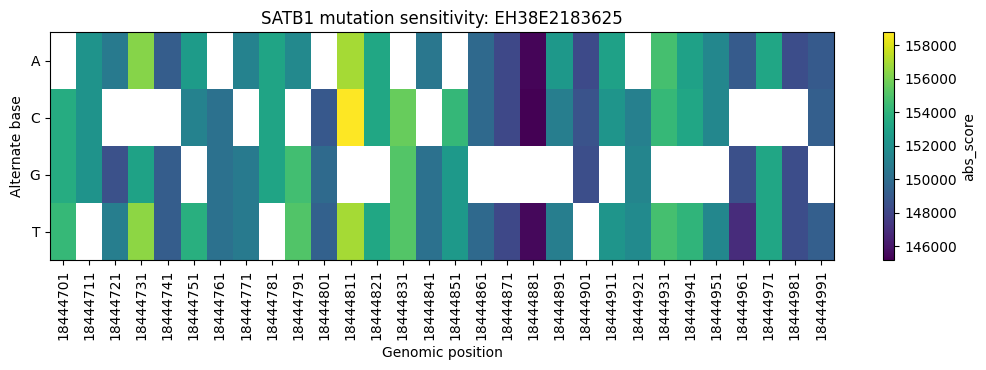

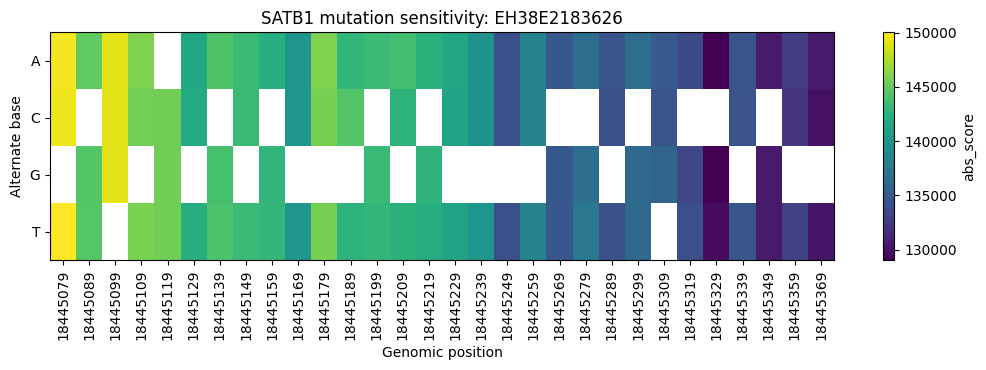

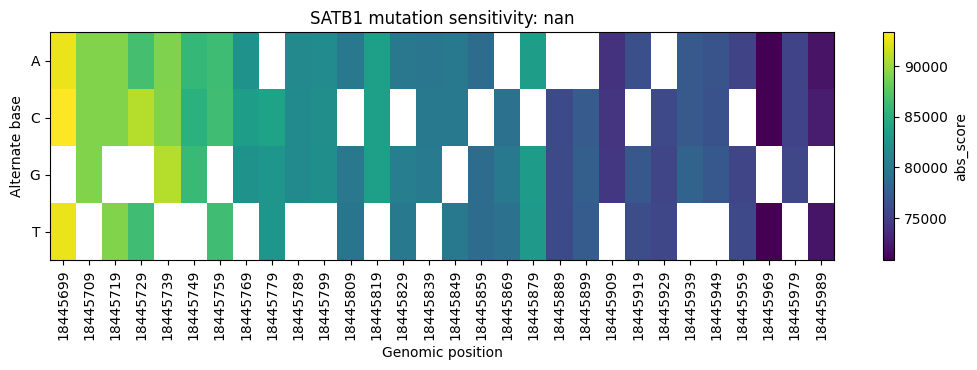

Saved heatmaps:
  alphagenome_project_outputs/SATB1/heatmaps/SATB1_EH38E2183625_heatmap.png
  alphagenome_project_outputs/SATB1/heatmaps/SATB1_EH38E2183626_heatmap.png
  alphagenome_project_outputs/SATB1/heatmaps/SATB1_nan_heatmap.png


In [24]:
# @title Plot and save per-region heatmaps
import re
import matplotlib.pyplot as plt

heatmap_output_dir = os.path.join(gene_output_dir, 'heatmaps')
os.makedirs(heatmap_output_dir, exist_ok=True)

def safe_filename(text):
    return re.sub(r'[^A-Za-z0-9_.-]+', '_', str(text))[:120]

heatmap_files = []

for region_id, region_df in variant_summary_by_score.groupby('region_id', dropna=False):
    pivot = (
        region_df.pivot_table(
            index='alternate_base',
            columns='position',
            values='abs_score',
            aggfunc='max',
        )
        .reindex(['A', 'C', 'G', 'T'])
        .dropna(how='all')
    )

    if pivot.empty:
        continue

    fig_width = max(10, pivot.shape[1] * 0.35)
    plt.figure(figsize=(fig_width, 3.8))
    plt.imshow(pivot.values, aspect='auto')
    plt.yticks(range(len(pivot.index)), pivot.index)
    plt.xticks(range(len(pivot.columns)), pivot.columns, rotation=90)
    plt.xlabel('Genomic position')
    plt.ylabel('Alternate base')
    plt.title(f'{gene_symbol} mutation sensitivity: {region_id}')
    plt.colorbar(label='abs_score')
    plt.tight_layout()

    out_png = os.path.join(heatmap_output_dir, f'{safe_gene}_{safe_filename(region_id)}_heatmap.png')
    plt.savefig(out_png, dpi=200)
    plt.show()
    heatmap_files.append(out_png)

print('Saved heatmaps:')
for f in heatmap_files:
    print(' ', f)

## 11. Select the top mutation for single-variant visualization

Use this cell to select a mutation to rerun in the original AlphaGenome single-variant visualization notebook.

Two choices are printed:

- **Top overall mutation:** largest absolute AlphaGenome score.
- **Top biologically ranked mutation:** prioritizes immune/Treg/T-cell metadata matches first, then score.

For the project, prefer the biologically ranked result when it is available and makes sense.

In [25]:
# @title Print top variants to copy into the original variant visualization notebook

def print_variant_for_original_notebook(row, label):
    print(f'\n{label}')
    print('-' * len(label))
    print(f"variant_chromosome = '{row['chromosome']}'")
    print(f"variant_position = {int(row['position'])}")
    print(f"variant_reference_bases = '{row['reference_base']}'")
    print(f"variant_alternate_bases = '{row['alternate_base']}'")
    print(f"# Variant: {row['variant_id_custom']}")
    for c in ['gene_symbol', 'region_id', 'candidate_class', 'output_type', 'track_name', 'biosample_name', 'biosample_type', 'abs_score', 'bio_relevance_score']:
        if c in row.index:
            print(f"# {c}: {row[c]}")

# Top overall.
top_overall = variant_summary_by_score.iloc[0]
print_variant_for_original_notebook(top_overall, 'Top overall mutation')

# Top with biological relevance ranking.
top_bio = variant_summary_bio_ranked.iloc[0]
print_variant_for_original_notebook(top_bio, 'Top biologically ranked mutation')

# Optional: choose the top variant within the top biologically relevant variable track.
if not track_variance_bio_ranked.empty:
    selected_track = track_variance_bio_ranked.iloc[0]
    print('\nTop biologically ranked variable track')
    print('-------------------------------------')
    display(pd.DataFrame([selected_track]))

    track_mask = pd.Series(True, index=df_filtered_scores.index)
    for c in ['region_id', 'output_type', 'track_name', 'biosample_name', 'biosample_type']:
        if c in selected_track.index and c in df_filtered_scores.columns:
            # Compare as strings to avoid NaN equality problems.
            track_mask &= df_filtered_scores[c].astype(str).eq(str(selected_track[c]))

    selected_track_rows = df_filtered_scores[track_mask].copy()
    if not selected_track_rows.empty:
        selected_score_col = detect_numeric_score_column(selected_track_rows)
        selected_track_rows['score_numeric'] = pd.to_numeric(selected_track_rows[selected_score_col], errors='coerce')
        selected_track_rows['abs_score'] = selected_track_rows['score_numeric'].abs()
        top_for_track = selected_track_rows.sort_values('abs_score', ascending=False).iloc[0]
        print_variant_for_original_notebook(top_for_track, 'Top mutation in selected variable track')



Top overall mutation
--------------------
variant_chromosome = 'chr3'
variant_position = 18444811
variant_reference_bases = 'G'
variant_alternate_bases = 'C'
# Variant: chr3:18444811:G>C
# gene_symbol: SATB1
# region_id: EH38E2183625
# output_type: CHIP_HISTONE
# track_name: CL:0000624 Histone ChIP-seq H3K4me3
# biosample_name: CD4-positive, alpha-beta T cell
# biosample_type: primary_cell
# abs_score: 158780.0
# bio_relevance_score: 2

Top biologically ranked mutation
--------------------------------
variant_chromosome = 'chr3'
variant_position = 18444811
variant_reference_bases = 'G'
variant_alternate_bases = 'C'
# Variant: chr3:18444811:G>C
# gene_symbol: SATB1
# region_id: EH38E2183625
# output_type: CHIP_HISTONE
# track_name: CL:0000624 Histone ChIP-seq H3K4me3
# biosample_name: CD4-positive, alpha-beta T cell
# biosample_type: primary_cell
# abs_score: 158780.0
# bio_relevance_score: 2

Top biologically ranked variable track
-------------------------------------


,gene_symbol,region_id,output_type,track_name,biosample_name,biosample_type,n_scores,n_variants,max_abs_score,mean_abs_score,score_variance,bio_relevance_score
0,SATB1,EH38E2183626,CHIP_HISTONE,CL:0000792 Histone ChIP-seq H3K27ac,"CD4-positive, CD25-positive, alpha-beta regula...",primary_cell,180,90,48508.0,22964.521484,530965120.0,4



Top mutation in selected variable track
---------------------------------------
variant_chromosome = 'chr3'
variant_position = 18445309
variant_reference_bases = 'T'
variant_alternate_bases = 'G'
# Variant: chr3:18445309:T>G
# gene_symbol: SATB1
# region_id: EH38E2183626
# candidate_class: promoter_like
# output_type: CHIP_HISTONE
# track_name: CL:0000792 Histone ChIP-seq H3K27ac
# biosample_name: CD4-positive, CD25-positive, alpha-beta regulatory T cell
# biosample_type: primary_cell
# abs_score: 48508.0


## 12. Zip outputs for download

Use this cell after the scan has finished.

In [26]:
# @title Zip and optionally download outputs
import shutil

zip_base = os.path.join(output_root, f'{safe_gene}_alphagenome_project_outputs')
zip_path = shutil.make_archive(zip_base, 'zip', gene_output_dir)
print('Created:', zip_path)

if download_scan_outputs:
    files.download(zip_path)

Created: /content/alphagenome_project_outputs/SATB1_alphagenome_project_outputs.zip


## 13. How to continue the project

After FOXP3 works:

1. Change `gene_symbol` to `BACH2` and rerun candidate discovery + scan.
2. Change `gene_symbol` to `SATB1` and rerun.
3. Combine the three `*_variant_summary*.csv` files.
4. Take the top AlphaGenome variants into Evo2.
5. Compare AlphaGenome scores against Evo2 reference-vs-alternate likelihood changes.

For your report, the justification should look like:

> Candidate regions were identified programmatically by retrieving gene coordinates from Ensembl, expanding the local cis-regulatory neighborhood, and intersecting that region with Ensembl regulatory features and UCSC/ENCODE cCRE annotations. Candidate promoter-like and enhancer-like regions were converted into 300 bp scan windows and tested using AlphaGenome variant scoring.